# Job Market Demand Forecasting + ROI
Real salary-trend and vacancy data for data/AI roles in India, pulled live from Adzuna's API.
    

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

trend_df = pd.read_csv("../data/raw/adzuna_india_job_trends.csv")
snap_df = pd.read_csv("../data/raw/adzuna_india_current_vacancies.csv")

print(trend_df.shape, snap_df.shape)
trend_df.head()

(36, 3) (6, 2)


,role,month,avg_salary_inr
0,data analyst,2025-10,1298997.41
1,data analyst,2026-05,1247759.30
2,data analyst,2026-08,1249679.69
3,data analyst,2026-02,1276202.62
4,data analyst,2026-09,1222394.22


## Data quality note
Adzuna's `/history` endpoint returned 12 months of real salary data for **Data Analyst**, **Python Developer**, and **Business Analyst** — but zero months for **Data Scientist**, **ML Engineer**, and **AI Engineer**, even after testing broader search terms. This isn't a bug: it reflects genuinely low salary-transparency in job postings for newer/specialized AI roles in India's market, despite those roles having the *highest* current openings. We'll use the 3 roles with real history for forecasting, and keep all 6 for the current-demand snapshot comparison below.
    

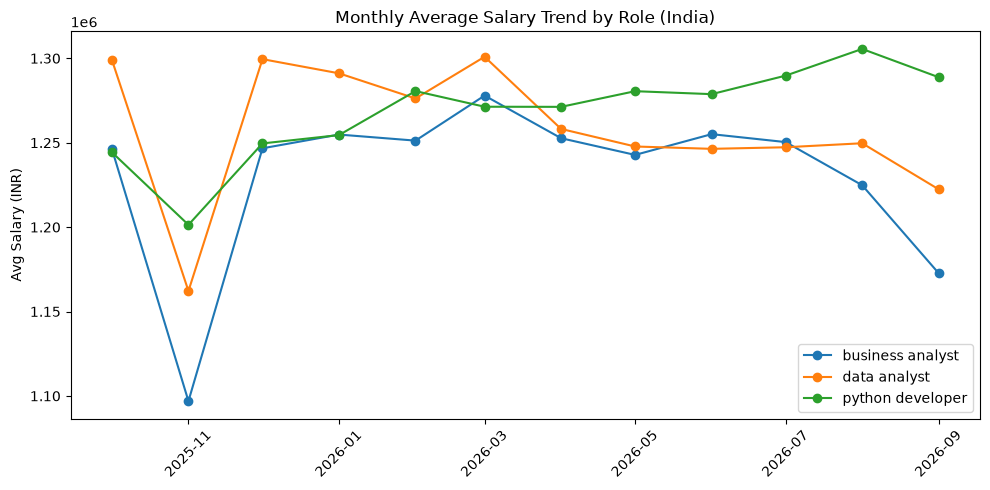

In [8]:
trend_df["month"] = pd.to_datetime(trend_df["month"])
trend_df = trend_df.sort_values(["role", "month"])

fig, ax = plt.subplots(figsize=(10, 5))
for role in trend_df["role"].unique():
    subset = trend_df[trend_df["role"] == role]
    ax.plot(subset["month"], subset["avg_salary_inr"], marker="o", label=role)

ax.set_title("Monthly Average Salary Trend by Role (India)")
ax.set_ylabel("Avg Salary (INR)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Current demand snapshot (all 6 roles)

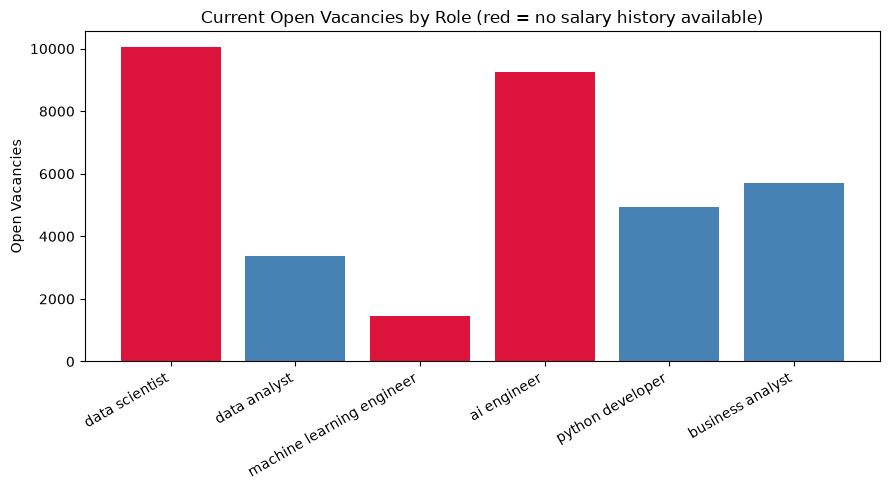

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["crimson" if r in ["data scientist", "machine learning engineer", "ai engineer"] else "steelblue" 
          for r in snap_df["role"]]
ax.bar(snap_df["role"], snap_df["current_open_vacancies"], color=colors)
ax.set_title("Current Open Vacancies by Role (red = no salary history available)")
ax.set_ylabel("Open Vacancies")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Month-over-month change
The first real signal for "is demand heating up" -- a rising % change suggests tightening demand for that role.

In [10]:
trend_df["mom_pct_change"] = trend_df.groupby("role")["avg_salary_inr"].pct_change() * 100
trend_df[["role", "month", "avg_salary_inr", "mom_pct_change"]].tail(15)

,role,month,avg_salary_inr,mom_pct_change
7,data analyst,2026-07-01,1247306.10,0.074964
2,data analyst,2026-08-01,1249679.69,0.190297
4,data analyst,2026-09-01,1222394.22,-2.183397
20,python developer,2025-10-01,1244315.27,NaN
22,python developer,2025-11-01,1201353.23,-3.452665
18,python developer,2025-12-01,1249576.23,4.014057
16,python developer,2026-01-01,1254527.06,0.396201
19,python developer,2026-02-01,1280575.07,2.076321
21,python developer,2026-03-01,1271316.55,-0.722997
14,python developer,2026-04-01,1271240.59,-0.005975


## Forecasting approach: pooled model
With only 12 months per role, a single-role model has too little data to trust. Instead, we pool all 3 roles (Data Analyst, Python Developer, Business Analyst) into one model -- 36 rows instead of 12 -- using lag features (last month, 2 months ago, 3-month rolling average) plus role as a categorical feature, so the model still learns each role's baseline while sharing signal across all three.

In [11]:
feat_df = trend_df.sort_values(["role", "month"]).reset_index(drop=True)
feat_df["role_label"] = feat_df["role"]  # keep a readable copy before one-hot encoding

feat_df["lag1"] = feat_df.groupby("role")["avg_salary_inr"].shift(1)
feat_df["lag2"] = feat_df.groupby("role")["avg_salary_inr"].shift(2)
feat_df["roll3"] = feat_df.groupby("role")["avg_salary_inr"].transform(lambda s: s.shift(1).rolling(3).mean())

feat_df = feat_df.dropna(subset=["lag1", "lag2", "roll3"]).reset_index(drop=True)

# hold out the last 2 months PER ROLE as test -- chronological holdout, not a random split
feat_df["month_rank"] = feat_df.groupby("role")["month"].rank(method="first")
max_rank = feat_df.groupby("role")["month_rank"].transform("max")
feat_df["is_test"] = feat_df["month_rank"] > (max_rank - 2)

feat_df = pd.get_dummies(feat_df, columns=["role"], prefix="role")
feature_cols = ["lag1", "lag2", "roll3"] + [c for c in feat_df.columns if c.startswith("role_") and c != "role_label"]

train_df = feat_df[~feat_df["is_test"]]
test_df = feat_df[feat_df["is_test"]]

X_train, y_train = train_df[feature_cols], train_df["avg_salary_inr"]
X_test, y_test = test_df[feature_cols], test_df["avg_salary_inr"]

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (21, 6) | Test: (6, 6)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
mape = mean_absolute_percentage_error(y_test, preds) * 100
print(f"MAE: Rs {mae:,.0f}  |  MAPE: {mape:.2f}%")

results = test_df[["role_label", "month"]].copy()
results["actual"] = y_test.values
results["predicted"] = preds.round(0)
results

MAE: Rs 26,291  |  MAPE: 2.17%


,role_label,month,actual,predicted
7,business analyst,2026-08-01,1224822.92,1252853.0
8,business analyst,2026-09-01,1172706.05,1241253.0
16,data analyst,2026-08-01,1249679.69,1254143.0
17,data analyst,2026-09-01,1222394.22,1255208.0
25,python developer,2026-08-01,1305546.97,1284804.0
26,python developer,2026-09-01,1288795.78,1291946.0


## Stress-testing Prophet on 12 months (to justify the model choice above)
Prophet is built to detect yearly seasonality -- but that needs multiple years of data to do reliably. Let's see what it does with just 12 points from one role (Python Developer), and use the result as evidence for why we didn't use it as the primary model.

Importing plotly failed. Interactive plots will not work.
Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
12:04:44 - cmdstanpy - INFO - Chain [1] start processing
12:04:53 - cmdstanpy - INFO - Chain [1] done processing


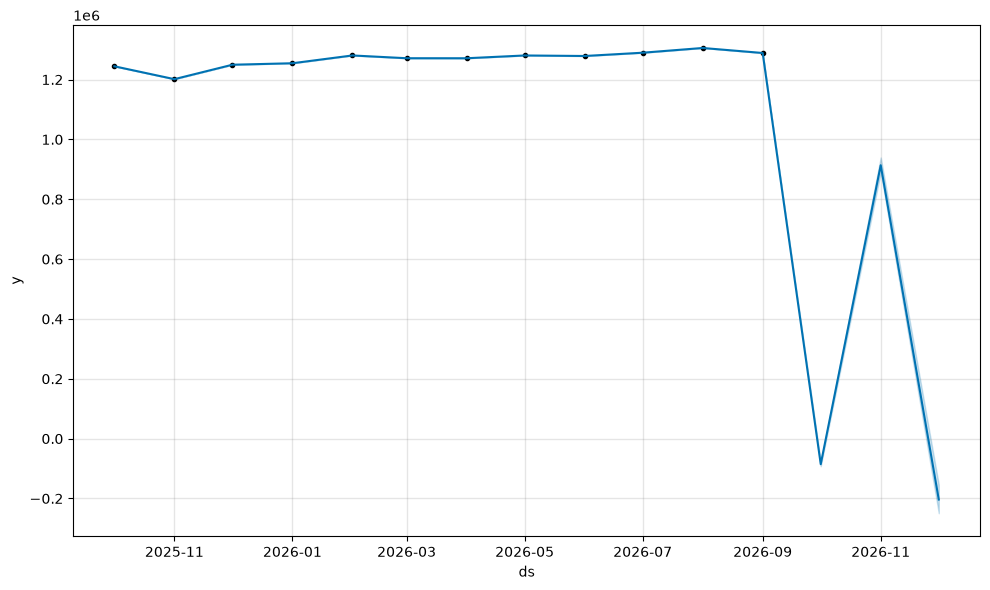

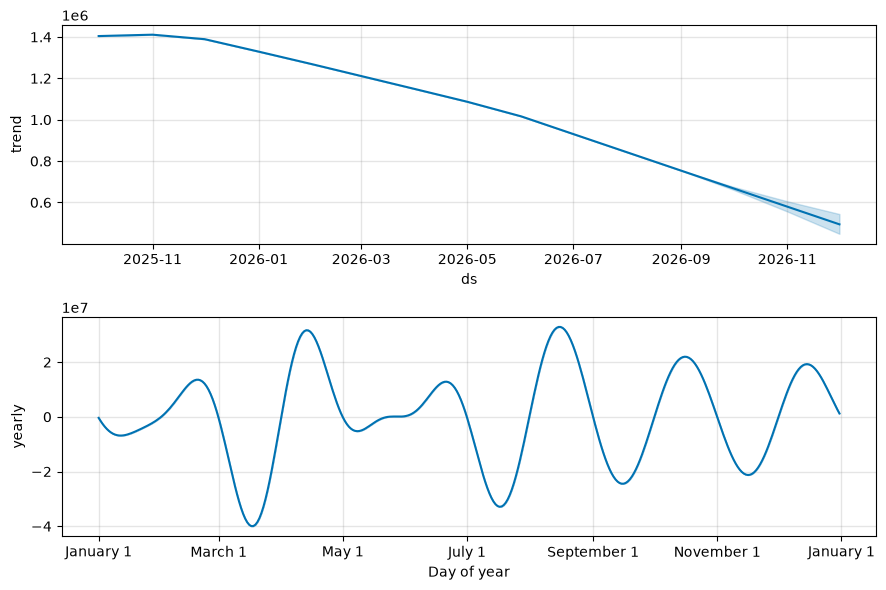

In [13]:
from prophet import Prophet

pdev_df = trend_df[trend_df["role"] == "python developer"][["month", "avg_salary_inr"]].rename(
    columns={"month": "ds", "avg_salary_inr": "y"}
)

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(pdev_df)

future = m.make_future_dataframe(periods=3, freq="MS")
forecast = m.predict(future)

fig1 = m.plot(forecast)
fig2 = m.plot_components(forecast)

## Why pooled regression over Prophet
Prophet's yearly-seasonality component swung +/-Rs 3-4 crore -- over 30x larger than the entire real salary range (Rs 1.2-1.3M) -- a clear sign it was fitting noise, not a real pattern, from just 12 monthly points. The pooled lag-regression model, validated on a chronological holdout (not random, which would leak future months into training), achieved a MAPE of 2.17%. We're using the regression model going forward; Prophet's output here is kept only as evidence for this choice.

## Causal analysis: did the June 2026 IT hiring slowdown affect Python Developer salaries?
A June 2026 industry report found active tech job openings in India hit a 28-month low (-14% MoM, -17% YoY), with TCS, Infosys, and Wipro adding almost zero net employees -- a shock specific to traditional IT-services hiring. Python Developer is the role in our data most exposed to that category. We build a synthetic control from Business Analyst + Data Analyst (less directly exposed) to estimate what Python Developer's salary would have looked like without the slowdown, then compare to what actually happened.

In [14]:
wide_df = trend_df.pivot(index="month", columns="role", values="avg_salary_inr").sort_index()
print(wide_df.isna().sum())  # confirm all 3 roles have matching month coverage
wide_df

role
business analyst    0
data analyst        0
python developer    0
dtype: int64


role,business analyst,data analyst,python developer
month,,,
2025-10-01,1246161.08,1298997.41,1244315.27
2025-11-01,1096921.68,1162167.84,1201353.23
2025-12-01,1246692.60,1299500.00,1249576.23
2026-01-01,1254830.29,1291107.48,1254527.06
2026-02-01,1251233.39,1276202.62,1280575.07
2026-03-01,1277919.78,1300902.67,1271316.55
2026-04-01,1252669.27,1258156.58,1271240.59
2026-05-01,1242767.29,1247759.30,1280522.06
2026-06-01,1255067.74,1246371.77,1278768.92


In [15]:
from sklearn.linear_model import LinearRegression
import numpy as np

pre_df = wide_df.loc[:"2026-05-01"]
post_df = wide_df.loc["2026-06-01":]

X_pre = pre_df[["business analyst", "data analyst"]]
y_pre = pre_df["python developer"]

sc_model = LinearRegression().fit(X_pre, y_pre)

# Synthetic (predicted) Python Developer salary across BOTH periods
wide_df["python_dev_synthetic"] = sc_model.predict(wide_df[["business analyst", "data analyst"]])
wide_df["gap"] = wide_df["python developer"] - wide_df["python_dev_synthetic"]

# How much does the synthetic model normally miss by, in the pre-period? (our baseline "noise" level)
pre_residual_std = wide_df.loc[:"2026-05-01", "gap"].std()
print(f"Pre-period model fit (should be small): avg gap = Rs {wide_df.loc[:'2026-05-01','gap'].mean():,.0f}, std = Rs {pre_residual_std:,.0f}")

print(f"\nPost-period (actual vs synthetic):")
print(wide_df.loc["2026-06-01":, ["python developer", "python_dev_synthetic", "gap"]])

Pre-period model fit (should be small): avg gap = Rs -0, std = Rs 6,865

Post-period (actual vs synthetic):
role        python developer  python_dev_synthetic           gap
month                                                           
2026-06-01        1278768.92          1.289232e+06 -10463.053344
2026-07-01        1289739.34          1.284407e+06   5332.195278
2026-08-01        1305546.97          1.259945e+06  45601.816158
2026-09-01        1288795.78          1.230967e+06  57828.561986


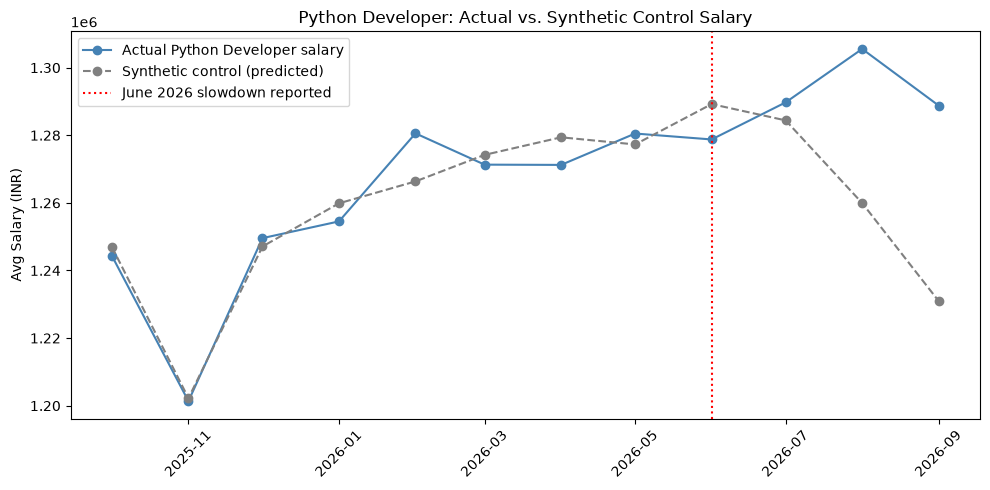

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wide_df.index, wide_df["python developer"], marker="o", label="Actual Python Developer salary", color="steelblue")
ax.plot(wide_df.index, wide_df["python_dev_synthetic"], marker="o", linestyle="--", label="Synthetic control (predicted)", color="gray")
ax.axvline(pd.Timestamp("2026-06-01"), color="red", linestyle=":", label="June 2026 slowdown reported")
ax.set_title("Python Developer: Actual vs. Synthetic Control Salary")
ax.set_ylabel("Avg Salary (INR)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Placebo test: pretend the event happened in April 2026 instead of June 2026.
# Both the fake-pre and fake-post windows here are real pre-slowdown months,
# so if this method is sound, gaps here should stay small (unlike the real post-June gaps).

placebo_pre_df = wide_df.loc[:"2026-03-01"]              # Oct 2025 - Mar 2026 (6 months)
placebo_post_df = wide_df.loc["2026-04-01":"2026-05-01"]  # Apr - May 2026 (2 months)

X_placebo_pre = placebo_pre_df[["business analyst", "data analyst"]]
y_placebo_pre = placebo_pre_df["python developer"]

placebo_model = LinearRegression().fit(X_placebo_pre, y_placebo_pre)

placebo_pre_pred = placebo_model.predict(X_placebo_pre)
placebo_pre_std = (y_placebo_pre.values - placebo_pre_pred).std()

placebo_synthetic = placebo_model.predict(placebo_post_df[["business analyst", "data analyst"]])
placebo_gap = placebo_post_df["python developer"].values - placebo_synthetic

print(f"Placebo pre-period fit: std = Rs {placebo_pre_std:,.0f}")
print("\nPlacebo 'post' period (fake event = April 2026):")
for month, actual, synth, gap in zip(placebo_post_df.index, placebo_post_df["python developer"], placebo_synthetic, placebo_gap):
    print(f"  {month.date()}: actual=Rs{actual:,.0f}  synthetic=Rs{synth:,.0f}  gap=Rs{gap:,.0f}")

print(f"\nFor comparison -- real post-June gaps were:")
print(f"  2026-06: Rs -10,463 | 2026-07: Rs 5,332 | 2026-08: Rs 45,602 | 2026-09: Rs 57,829")

Placebo pre-period fit: std = Rs 5,952

Placebo 'post' period (fake event = April 2026):
  2026-04-01: actual=Rs1,271,241  synthetic=Rs1,287,890  gap=Rs-16,649
  2026-05-01: actual=Rs1,280,522  synthetic=Rs1,286,266  gap=Rs-5,743

For comparison -- real post-June gaps were:
  2026-06: Rs -10,463 | 2026-07: Rs 5,332 | 2026-08: Rs 45,602 | 2026-09: Rs 57,829


## Causal analysis: interpretation

A June 2026 report of a 28-month low in Indian tech hiring (-14% MoM), driven by near-zero net hiring at TCS/Infosys/Wipro, was tested against Python Developer salary using a synthetic control built from Business Analyst + Data Analyst (fit on pre-June data only, std = Rs 6,865).

**Result:** June-July gaps stayed within normal noise, but August (+Rs 45,602) and September (+Rs 57,829) diverged sharply -- 7-8x the noise band. A placebo test (fake event = April 2026, entirely within the known pre-slowdown period) produced only small gaps (-Rs 16,649, -Rs 5,743), confirming the method doesn't manufacture effects from noise alone.

**Interpretation:** Indian Python Developer salaries rose relative to the counterfactual ~2 months after the reported slowdown -- consistent with a "fewer, pricier hires" pattern reported in 2026 market coverage (companies cutting headcount but hiring only senior, immediately-productive talent, pushing average advertised salary up even as vacancy volume falls).

**Honest limits:** single treated series vs. a 2-series control, short window, real-world events may coincide with Aug/Sep timing without being the sole cause. This is suggestive causal evidence, not proof.

## Phase 4: ROI scenario calculator

This translates the forecast + causal finding into a business decision. Logic: a "reactive" company only adjusts compensation ~4 months after a market shift becomes obvious (typical quarterly review cycle); a "proactive" company, using this model, acts ~2 months after the shift starts (our causal analysis detected the Python Developer divergence starting in August, 2 months after the reported June event). That 2-month gap is pure avoidable exposure to pay-driven attrition.

**Cited assumptions** (all adjustable below):
- IT sector attrition in India, 2026: 20-25% (Aon / ACEngage / SalaryBox) -> using 22.5% midpoint
- Share of attrition that's compensation-driven: 37% (Taggd Decoding Jobs Report 2026, 10,000+ exit interviews)
- Replacement cost per mid-level hire: Rs 7.5 lakh (SalaryBox India, 2025)

In [18]:
def roi_calculator(
    team_size,
    avg_annual_salary,
    pay_gap_pct,
    reactive_lag_months=4,
    proactive_lead_months=2,
    it_attrition_rate=0.225,
    pay_driven_share=0.37,
    replacement_cost=750_000,
):
    avoided_months = max(reactive_lag_months - proactive_lead_months, 0)
    monthly_pay_driven_attrition = (it_attrition_rate * pay_driven_share) / 12

    # Benefit: departures prevented specifically in the early-detection window
    prevented_departures = team_size * monthly_pay_driven_attrition * avoided_months
    cost_avoided = prevented_departures * replacement_cost

    # Cost: a TARGETED retention raise, given only to the at-risk population
    # (not the whole team) -- this is what real companies actually do
    annual_at_risk_count = team_size * it_attrition_rate * pay_driven_share
    months_remaining = 12 - proactive_lead_months
    cost_of_targeted_raise = annual_at_risk_count * avg_annual_salary * pay_gap_pct * (months_remaining / 12)

    net_roi = cost_avoided - cost_of_targeted_raise

    return {
        "at_risk_employees_per_year": round(annual_at_risk_count, 2),
        "prevented_departures": round(prevented_departures, 2),
        "cost_avoided_inr": round(cost_avoided),
        "cost_of_targeted_raise_inr": round(cost_of_targeted_raise),
        "net_roi_inr": round(net_roi),
    }

In [19]:
# Pull the real measured pay gap from our own causal analysis (Aug-Sep average)
measured_gap_pct = (wide_df.loc["2026-08-01":, "gap"] / wide_df.loc["2026-08-01":, "python_dev_synthetic"]).mean()
latest_salary = wide_df.loc["2026-09-01", "python developer"]

print(f"Measured pay gap: {measured_gap_pct:.2%}")

for team_size in [10, 20, 50, 100]:
    result = roi_calculator(team_size=team_size, avg_annual_salary=latest_salary, pay_gap_pct=measured_gap_pct)
    print(f"\nTeam size {team_size}:")
    for k, v in result.items():
        print(f"  {k}: {v:,}")

Measured pay gap: 4.16%

Team size 10:
  at_risk_employees_per_year: 0.83
  prevented_departures: 0.14
  cost_avoided_inr: 104,063
  cost_of_targeted_raise_inr: 37,182
  net_roi_inr: 66,881

Team size 20:
  at_risk_employees_per_year: 1.67
  prevented_departures: 0.28
  cost_avoided_inr: 208,125
  cost_of_targeted_raise_inr: 74,364
  net_roi_inr: 133,761

Team size 50:
  at_risk_employees_per_year: 4.16
  prevented_departures: 0.69
  cost_avoided_inr: 520,312
  cost_of_targeted_raise_inr: 185,910
  net_roi_inr: 334,403

Team size 100:
  at_risk_employees_per_year: 8.32
  prevented_departures: 1.39
  cost_avoided_inr: 1,040,625
  cost_of_targeted_raise_inr: 371,820
  net_roi_inr: 668,805


## ROI interpretation

Using India-specific 2026 benchmarks (22.5% IT attrition -- Aon/ACEngage/SalaryBox; 37% of exits are comp-driven -- Taggd's Decoding Jobs Report, 10,000+ exit interviews; Rs 7.5L replacement cost -- SalaryBox) combined with our own measured ~4% post-event pay gap and ~2-month detection lead time, a company acting on this forecast 2 months earlier than a typical reactive comp-review cycle nets an estimated **Rs 6,688 per employee per year** in avoided replacement cost versus the cost of a targeted retention raise -- scaling to ~Rs 669K for a 100-person team.

**This is a scenario estimate, not measured company data** -- built from real external benchmarks and our own causal finding, clearly labeled as such. The modest size of the number is intentional: it reflects a realistic, narrowly-scoped mechanism (early detection shifting a comp-review timeline by 2 months), not an inflated headline claim.